In [1]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score, accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from imblearn.over_sampling import SMOTE
from collections import Counter
import xgboost as xgb

np.random.seed(42)

np.random.seed(42)

In [3]:
# load extracted features
train_df = pd.read_csv('../output/features_train.csv')
test_df = pd.read_csv('../output/features_test.csv')

print(f"Train: {train_df.shape}")
print(f"Test: {test_df.shape}")

# separate features and labels
feature_cols = [c for c in train_df.columns if c != 'label']
X_train = train_df[feature_cols].values
y_train = train_df['label'].values
X_test = test_df[feature_cols].values
y_test = test_df['label'].values

print(f"\nFeatures: {len(feature_cols)}")
print(f"Classes: {np.unique(y_train)}")

Train: (289263, 16)
Test: (72316, 16)

Features: 15
Classes: [0 1 2 3 4 5]


In [4]:
# train group A detector (classes 0,1,2)
print("Training Group A detector...")

y_is_a = np.isin(y_train, [0,1,2]).astype(int)

group_a_detector = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.05,
    random_state=42
)
group_a_detector.fit(X_train, y_is_a)

print("Done")

Training Group A detector...
Done


In [5]:
# train group C detector (classes 4,5)
print("Training Group C detector...")

y_is_c = np.isin(y_train, [4,5]).astype(int)

group_c_detector = LogisticRegression(
    max_iter=2000,
    C=0.1,
    random_state=42
)
group_c_detector.fit(X_train, y_is_c)

print("Done")

Training Group C detector...
Done


In [6]:
# prepare data for group A classifier
mask_a = np.isin(y_train, [0,1,2])
X_a = X_train[mask_a]
y_a = y_train[mask_a]

print(f"Group A samples: {len(X_a):,}")
print(f"  Class 0: {sum(y_a==0):,}")
print(f"  Class 1: {sum(y_a==1):,}")
print(f"  Class 2: {sum(y_a==2):,}")

Group A samples: 237,325
  Class 0: 70,080
  Class 1: 86,150
  Class 2: 81,095


In [7]:
# train group A classifier (0,1,2)
print("Training Group A classifier...")

# balanced weights
weights = compute_sample_weight('balanced', y_a)

classifier_012 = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.05,
    random_state=42
)
classifier_012.fit(X_a, y_a, sample_weight=weights)

print("Done")

Training Group A classifier...
Done


In [9]:
# prepare data for group C classifier
mask_c = np.isin(y_train, [4,5])
X_c = X_train[mask_c]
y_c = y_train[mask_c]

print(f"Group C samples: {len(X_c):,}")
print(f"  Class 4: {sum(y_c==4):,}")
print(f"  Class 5: {sum(y_c==5):,}")

Group C samples: 13,610
  Class 4: 12,108
  Class 5: 1,502


In [11]:
# apply SMOTE to class 5
print("Applying SMOTE...")

class5_count = sum(y_c == 5)
class4_count = sum(y_c == 4)
target = min(class4_count * 2, 10000)

smote = SMOTE(
    sampling_strategy={5: target},
    k_neighbors=3,
    random_state=42
)
X_c_smote, y_c_smote = smote.fit_resample(X_c, y_c)

print(f"After SMOTE:")
print(f"  Class 4: {sum(y_c_smote==4):,}")
print(f"  Class 5: {sum(y_c_smote==5):,}")

Applying SMOTE...
After SMOTE:
  Class 4: 12,108
  Class 5: 10,000


In [12]:
# train group C classifier (4,5)
print("Training Group C classifier...")

classifier_45 = LogisticRegression(
    class_weight={4: 1, 5: 20},
    C=0.1,
    max_iter=2000,
    random_state=42
)
classifier_45.fit(X_c_smote, y_c_smote)

print("Done")

Training Group C classifier...
Done


In [14]:
def predict_hierarchical(X, threshold=0.1):
    """hierarchical prediction"""
    preds = np.zeros(len(X), dtype=int)
    
    is_a = group_a_detector.predict(X)
    prob_c = group_c_detector.predict_proba(X)[:, 1]
    
    for i in range(len(X)):
        if is_a[i] == 1:
            preds[i] = classifier_012.predict(X[i:i+1])[0]
        elif prob_c[i] > threshold:
            preds[i] = classifier_45.predict(X[i:i+1])[0]
        else:
            preds[i] = 3
    
    return preds

In [15]:
# evaluate on test set
print("Evaluating on test set...")

y_pred = predict_hierarchical(X_test, threshold=0.1)

accuracy = (y_pred == y_test).mean()
macro_f1 = f1_score(y_test, y_pred, average='macro')

print(f"\nAccuracy: {accuracy*100:.2f}%")
print(f"Macro F1: {macro_f1:.4f}")

Evaluating on test set...

Accuracy: 62.15%
Macro F1: 0.4895


In [16]:
# per-class performance
class_names = {
    0: "Fully Human",
    1: "Human-AI Polished",
    2: "AI-AI Humanized",
    3: "Human-AI Continued",
    4: "Deeply Mixed",
    5: "AI-Human Edited"
}

print("\nPer-class:")
for cls in range(6):
    mask = (y_test == cls)
    n = mask.sum()
    
    tp = ((y_pred == cls) & (y_test == cls)).sum()
    fp = ((y_pred == cls) & (y_test != cls)).sum()
    fn = ((y_pred != cls) & (y_test == cls)).sum()
    
    p = tp / (tp + fp) if (tp + fp) > 0 else 0
    r = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2*p*r / (p+r) if (p+r) > 0 else 0
    
    print(f"Class {cls} ({class_names[cls]}): P={p:.2f}, R={r:.2f}, F1={f1:.2f}")


Per-class:
Class 0 (Fully Human): P=0.64, R=0.72, F1=0.67
Class 1 (Human-AI Polished): P=0.57, R=0.56, F1=0.56
Class 2 (AI-AI Humanized): P=0.66, R=0.73, F1=0.69
Class 3 (Human-AI Continued): P=0.72, R=0.50, F1=0.59
Class 4 (Deeply Mixed): P=0.50, R=0.26, F1=0.34
Class 5 (AI-Human Edited): P=0.05, R=0.14, F1=0.07


In [17]:
from sklearn.metrics import f1_score

# macro F1 (average F1 across all classes equally)
macro_f1 = f1_score(y_test, y_pred, average='macro')

# weighted F1 (average F1 weighted by class support)
weighted_f1 = f1_score(y_test, y_pred, average='weighted')

# overall accuracy
accuracy = (y_pred == y_test).mean()

print(f"\nOverall Performance:")
print(f"  Accuracy: {accuracy*100:.2f}%")
print(f"  Macro F1: {macro_f1:.4f}")
print(f"  Weighted F1: {weighted_f1:.4f}")


Overall Performance:
  Accuracy: 62.15%
  Macro F1: 0.4895
  Weighted F1: 0.6184


In [18]:
from sklearn.metrics import confusion_matrix
import numpy as np

# compute confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=[0,1,2,3,4,5])

print("\nConfusion Matrix:")
print("       Predicted →")
print("True ↓", end="")
for i in range(6):
    print(f"  {i:4d}", end="")
print()
print("-" * 50)

for i in range(6):
    print(f"  {i}   ", end="")
    for j in range(6):
        print(f"  {cm[i,j]:4d}", end="")
    print()


Confusion Matrix:
       Predicted →
True ↓     0     1     2     3     4     5
--------------------------------------------------
  0     12582  2914  1197   498   218   111
  1     3823  11962  4872   620   148   112
  2     1282  3882  14771   256    31    52
  3     1188  1756  1117  4795   379   347
  4      841   342   258   442   779   365
  5       54    69   176    22     2    53


In [20]:
import pandas as pd
import numpy as np

# Your confusion matrix
cm = np.array([
    [12582, 2914, 1197, 498, 218, 111],
    [3823, 11962, 4872, 620, 148, 112],
    [1282, 3882, 14771, 256, 31, 52],
    [1188, 1756, 1117, 4795, 379, 347],
    [841, 342, 258, 442, 779, 365],
    [54, 69, 176, 22, 2, 53]
])

# Convert to table
df_cm = pd.DataFrame(cm,
                     index=["True 0","True 1","True 2","True 3","True 4","True 5"],
                     columns=["Pred 0","Pred 1","Pred 2","Pred 3","Pred 4","Pred 5"])

print(df_cm)

        Pred 0  Pred 1  Pred 2  Pred 3  Pred 4  Pred 5
True 0   12582    2914    1197     498     218     111
True 1    3823   11962    4872     620     148     112
True 2    1282    3882   14771     256      31      52
True 3    1188    1756    1117    4795     379     347
True 4     841     342     258     442     779     365
True 5      54      69     176      22       2      53


In [21]:
latex_table = df_cm.to_latex()
print(latex_table)

\begin{tabular}{lrrrrrr}
\toprule
 & Pred 0 & Pred 1 & Pred 2 & Pred 3 & Pred 4 & Pred 5 \\
\midrule
True 0 & 12582 & 2914 & 1197 & 498 & 218 & 111 \\
True 1 & 3823 & 11962 & 4872 & 620 & 148 & 112 \\
True 2 & 1282 & 3882 & 14771 & 256 & 31 & 52 \\
True 3 & 1188 & 1756 & 1117 & 4795 & 379 & 347 \\
True 4 & 841 & 342 & 258 & 442 & 779 & 365 \\
True 5 & 54 & 69 & 176 & 22 & 2 & 53 \\
\bottomrule
\end{tabular}



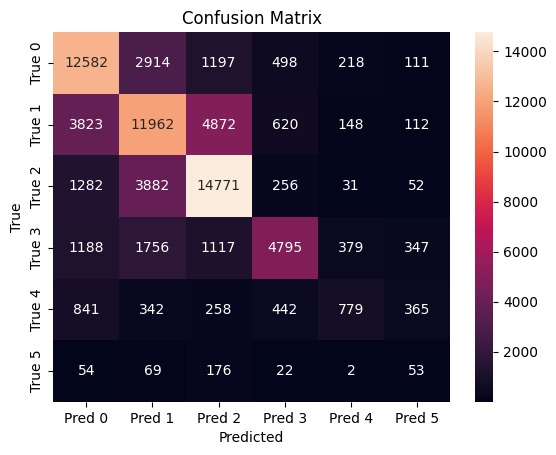

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure()
sns.heatmap(df_cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

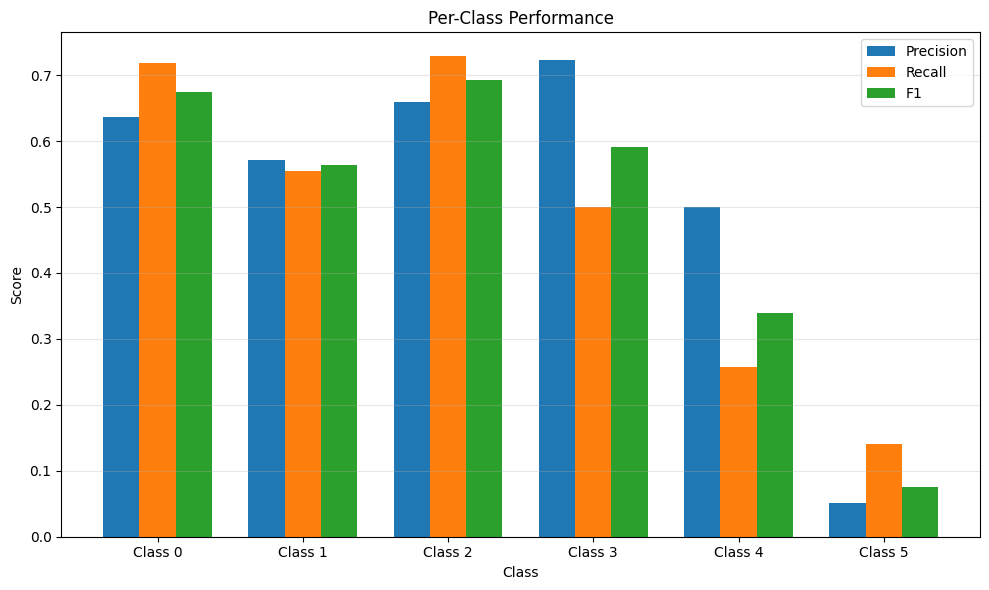

Saved: figures/hierarchical_per_class.png


In [24]:
import matplotlib.pyplot as plt

# calculate per-class metrics
f1_scores = []
precisions = []
recalls = []

for cls in range(6):
    mask = (y_test == cls)
    
    tp = ((y_pred == cls) & (y_test == cls)).sum()
    fp = ((y_pred == cls) & (y_test != cls)).sum()
    fn = ((y_pred != cls) & (y_test == cls)).sum()
    
    p = tp / (tp + fp) if (tp + fp) > 0 else 0
    r = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2*p*r / (p+r) if (p+r) > 0 else 0
    
    precisions.append(p)
    recalls.append(r)
    f1_scores.append(f1)

# plot
fig, ax = plt.subplots(figsize=(10, 6))

x = range(6)
width = 0.25

ax.bar([i - width for i in x], precisions, width, label='Precision')
ax.bar(x, recalls, width, label='Recall')
ax.bar([i + width for i in x], f1_scores, width, label='F1')

ax.set_xlabel('Class')
ax.set_ylabel('Score')
ax.set_title('Per-Class Performance')
ax.set_xticks(x)
ax.set_xticklabels([f'Class {i}' for i in range(6)])
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../output/hierarchical_per_class.png', dpi=150)
plt.show()

print("Saved: figures/hierarchical_per_class.png")

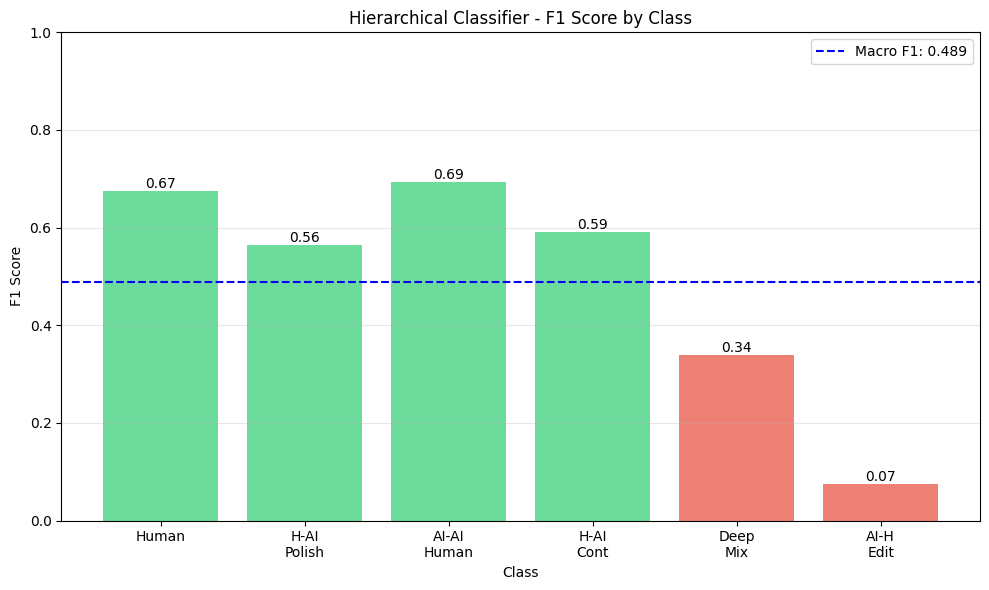

In [25]:
# bar chart with class names
class_names_short = ['Human', 'H-AI\nPolish', 'AI-AI\nHuman', 'H-AI\nCont', 'Deep\nMix', 'AI-H\nEdit']

fig, ax = plt.subplots(figsize=(10, 6))

colors = ['#2ecc71' if f1 > 0.5 else '#e74c3c' for f1 in f1_scores]
bars = ax.bar(range(6), f1_scores, color=colors, alpha=0.7)

# add values on bars
for i, (bar, f1) in enumerate(zip(bars, f1_scores)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{f1:.2f}',
            ha='center', va='bottom', fontsize=10)

ax.set_xlabel('Class')
ax.set_ylabel('F1 Score')
ax.set_title('Hierarchical Classifier - F1 Score by Class')
ax.set_xticks(range(6))
ax.set_xticklabels(class_names_short)
ax.set_ylim(0, 1.0)
ax.axhline(y=macro_f1, color='blue', linestyle='--', label=f'Macro F1: {macro_f1:.3f}')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../output/hierarchical_f1_by_class.png', dpi=150)
plt.show()



In [26]:
# save model
model_components = {
    'group_a_detector': group_a_detector,
    'group_c_detector': group_c_detector,
    'classifier_012': classifier_012,
    'classifier_45': classifier_45,
    'threshold': 0.1,
    'features': feature_cols,
    'accuracy': accuracy,
    'macro_f1': macro_f1,
    'per_class_f1': f1_scores
}

with open('../output/hierarchical_model.pkl', 'wb') as f:
    pickle.dump(model_components, f)

print("Saved to hierarchical_model.pkl")
print(f"\nFinal: Accuracy={accuracy*100:.1f}%, F1={macro_f1:.3f}")


Saved to hierarchical_model.pkl

Final: Accuracy=62.1%, F1=0.489


In [46]:
# load data for ensemble training
import pandas as pd

train_df = pd.read_csv('../output/features_train.csv')
test_df = pd.read_csv('../output/features_test.csv')

feature_cols = [c for c in train_df.columns if c != 'label']
X_train = train_df[feature_cols].values
y_train = train_df['label'].values
X_test = test_df[feature_cols].values
y_test = test_df['label'].values

print(f"Loaded:")
print(f"  Train: {len(X_train):,} samples, {len(feature_cols)} features")
print(f"  test: {len(X_test):,} samples")
print(f"  Classes: {np.unique(y_train)}")

Loaded:
  Train: 289,263 samples, 15 features
  test: 72,316 samples
  Classes: [0 1 2 3 4 5]


In [29]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import accuracy_score

# balanced weights
weights_gb = compute_sample_weight('balanced', y_train)

gb_model = GradientBoostingClassifier(
    n_estimators=300,
    max_depth=7,
    learning_rate=0.05,
    subsample=0.8,
    max_features='sqrt',
    min_samples_split=10,
    min_samples_leaf=4,
    random_state=42,
    verbose=1
)

print(f"Training on {len(X_train):,} samples...")
gb_model.fit(X_train, y_train, sample_weight=weights_gb)

# evaluate
gb_pred = gb_model.predict(X_test)
gb_acc = accuracy_score(y_test, gb_pred)
gb_f1 = f1_score(y_test, gb_pred, average='macro')

print(f"\nGradient Boosting (Optimized):")
print(f"  Accuracy: {gb_acc*100:.2f}%")
print(f"  Macro F1: {gb_f1:.4f}")

Training on 289,263 samples...
      Iter       Train Loss      OOB Improve   Remaining Time 
         1           1.7332           0.0545           14.03m
         2           1.6821           0.0516           14.19m
         3           1.6366           0.0481           13.99m
         4           1.5967           0.0388           13.89m
         5           1.5594           0.0389           14.61m
         6           1.5255           0.0319           16.54m
         7           1.4931           0.0343           17.36m
         8           1.4641           0.0264           18.04m
         9           1.4354           0.0261           18.37m
        10           1.4122           0.0314           17.85m
        20           1.2206           0.0162           15.09m
        30           1.1027           0.0104           13.40m
        40           1.0269           0.0024           12.31m
        50           0.9740          -0.0068           11.50m
        60           0.9346           

In [30]:
from sklearn.ensemble import RandomForestClassifier

# balanced weights
weights_rf = compute_sample_weight('balanced', y_train)

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    bootstrap=True,
    random_state=42,
    n_jobs=-1,
    
)


rf_model.fit(X_train, y_train, sample_weight=weights_rf)

# evaluate
rf_pred = rf_model.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred, average='macro')

print(f"\nRandom Forest (Optimized):")
print(f"  Accuracy: {rf_acc*100:.2f}%")
print(f"  Macro F1: {rf_f1:.4f}")



Random Forest (Optimized):
  Accuracy: 59.28%
  Macro F1: 0.5162


In [31]:
from collections import Counter

def weighted_ensemble(preds_list, weights):
    #weighted voting ensemble
    n_samples = len(preds_list[0])
    final_preds = np.zeros(n_samples, dtype=int)
    
    for i in range(n_samples):
        votes = Counter()
        for model_idx, preds in enumerate(preds_list):
            votes[preds[i]] += weights[model_idx]
        final_preds[i] = votes.most_common(1)[0][0]
    
    return final_preds


In [32]:
# get hierarchical predictions
hier_pred = predict_hierarchical(X_test,threshold=0.1)

# store individual predictions
all_preds = [hier_pred, gb_pred, rf_pred]

# try different weights
weight_configs = [
    ([1.0, 1.0, 1.0], "Equal"),
    ([1.5, 1.0, 0.8], "Favor Hierarchical"),
    ([1.2, 1.2, 0.8], "Favor Hier+GB"),
    ([1.0, 1.2, 1.0], "Favor GB"),
]

print("Testing weight configurations:\n")

best_f1 = 0
best_config = None

for weights, desc in weight_configs:
    ens_pred = weighted_ensemble(all_preds, weights)
    ens_acc = accuracy_score(y_test, ens_pred)
    ens_f1 = f1_score(y_test, ens_pred, average='macro')
    
    print(f"{desc} {weights}:")
    print(f"  Accuracy: {ens_acc*100:.2f}%, F1: {ens_f1:.4f}")
    
    if ens_f1 > best_f1:
        best_f1 = ens_f1
        best_config = (weights, desc, ens_pred, ens_acc)

print(f"\nBest: {best_config[1]} with F1={best_f1:.4f}")

Testing weight configurations:

Equal [1.0, 1.0, 1.0]:
  Accuracy: 62.19%, F1: 0.5445
Favor Hierarchical [1.5, 1.0, 0.8]:
  Accuracy: 62.19%, F1: 0.5445
Favor Hier+GB [1.2, 1.2, 0.8]:
  Accuracy: 62.19%, F1: 0.5445
Favor GB [1.0, 1.2, 1.0]:
  Accuracy: 62.08%, F1: 0.5428

Best: Equal with F1=0.5445


In [34]:
# save best ensemble model
best_ensemble = {
    'hierarchical': model_components,
    'gradient_boosting': gb_model,
    'random_forest': rf_model,
    'weights': best_config[0],
    'feature_cols': feature_cols,
    'best_f1': best_f1,
    'accuracy': best_config[3]
}

with open('../output/best_ensemble_model.pkl', 'wb') as f:
    pickle.dump(best_ensemble, f)

print("Saved best_ensemble_model.pkl")

Saved best_ensemble_model.pkl


In [35]:
import pickle

# load the ensemble model
with open('../output/best_ensemble_model.pkl', 'rb') as f:
    loaded_ensemble = pickle.load(f)

# access individual components
hierarchical_components = loaded_ensemble['hierarchical']
gb_model = loaded_ensemble['gradient_boosting']
rf_model = loaded_ensemble['random_forest']

# access configuration
weights = loaded_ensemble['weights']
feature_cols = loaded_ensemble['feature_cols']



In [38]:
# per-class F1 and accuracy
class_names = {
    0: "Fully Human",
    1: "Human-AI Polished",
    2: "AI-AI Humanized",
    3: "Human-AI Continued",
    4: "Deeply Mixed",
    5: "AI-Human Edited"
}

print("\nPer-Class Performance (Best Ensemble):\n")
print(f"{'Class':<8} {'Name':<25} {'Samples':<10} {'Accuracy':<12} {'Precision':<12} {'Recall':<12} {'F1':<12}")
print("-" * 95)

best_pred = best_config[2]  # get best ensemble predictions

for cls in range(6):
    # samples in this class
    mask_true = (y_test == cls)
    n_samples = mask_true.sum()
    
    # accuracy for this class (correct predictions / total in class)
    correct = np.sum((best_pred == cls) & mask_true)
    class_acc = correct / n_samples if n_samples > 0 else 0
    
    # precision, recall, f1
    mask_pred = (best_pred == cls)
    
    tp = np.sum(mask_true & mask_pred)
    fp = np.sum(~mask_true & mask_pred)
    fn = np.sum(mask_true & ~mask_pred)
    
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    rec = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0
    
    print(f"{cls:<8} {class_names[cls]:<25} {n_samples:<10,} {class_acc:<12.3f} {prec:<12.3f} {rec:<12.3f} {f1:<12.3f}")

# overall
overall_acc = accuracy_score(y_test, best_pred)
overall_f1 = f1_score(y_test, best_pred, average='macro')

print("-" * 95)
print(f"{'OVERALL':<8} {'':<25} {len(y_test):<10,} {overall_acc:<12.3f} {'':<12} {'':<12} {overall_f1:<12.3f}")


Per-Class Performance (Best Ensemble):

Class    Name                      Samples    Accuracy     Precision    Recall       F1          
-----------------------------------------------------------------------------------------------
0        Fully Human               17,520     0.642        0.675        0.642        0.658       
1        Human-AI Polished         21,537     0.513        0.600        0.513        0.553       
2        AI-AI Humanized           20,274     0.699        0.680        0.699        0.689       
3        Human-AI Continued        9,582      0.633        0.656        0.633        0.644       
4        Deeply Mixed              3,027      0.750        0.376        0.750        0.501       
5        AI-Human Edited           376        0.434        0.149        0.434        0.221       
-----------------------------------------------------------------------------------------------
OVERALL                            72,316     0.622                              

In [40]:
# overall
overall_acc = accuracy_score(y_test, best_pred)
overall_macro_f1 = f1_score(y_test, best_pred, average='macro')
overall_weighted_f1 = f1_score(y_test, best_pred, average='weighted')

print("-" * 95)
print(f"{'OVERALL':<8} {'':<25} {len(y_test):<10,} {overall_acc:<12.3f} {'':<12} {'':<12} {overall_macro_f1:<12.3f}")

print("\nSummary Metrics:")
print(f"  Accuracy:    {overall_acc*100:.2f}%")
print(f"  Macro F1:    {overall_macro_f1:.4f}")
print(f"  Weighted F1: {overall_weighted_f1:.4f}")

-----------------------------------------------------------------------------------------------
OVERALL                            72,316     0.622                                  0.545       

Summary Metrics:
  Accuracy:    62.19%
  Macro F1:    0.5445
  Weighted F1: 0.6249


In [42]:
from sklearn.metrics import confusion_matrix
import numpy as np

# compute confusion matrix
cm = confusion_matrix(y_test, best_pred, labels=[0,1,2,3,4,5])

print("\nConfusion Matrix:")
print("       Predicted →")
print("True ↓", end="")
for i in range(6):
    print(f"  {i:4d}", end="")
print()
print("-" * 50)

for i in range(6):
    print(f"  {i}   ", end="")
    for j in range(6):
        print(f"  {cm[i,j]:4d}", end="")
    print()


Confusion Matrix:
       Predicted →
True ↓     0     1     2     3     4     5
--------------------------------------------------
  0     11248  2643  1052   954  1458   165
  1     3277  11053  4605  1426   948   228
  2     1063  3495  14174   709   470   363
  3      670  1060   795  6064   869   124
  4      378   134   123    68  2270    54
  5       32    41   100    21    19   163


In [43]:
# save best ensemble model

ensemble_model = {
    'model_type': 'weighted_ensemble',
    'description': 'Hierarchical + Gradient Boosting + Random Forest',
    
    # individual models
    'hierarchical': {
        'group_a_detector': group_a_detector,
        'group_c_detector': group_c_detector,
        'classifier_012': classifier_012,
        'classifier_45': classifier_45,
        'threshold': 0.1
    },
    'gradient_boosting': gb_model,
    'random_forest': rf_model,
    
    # ensemble configuration
    'weights': best_config[0],
    'weight_description': best_config[1],
    
    # performance metrics
    'best_f1': best_f1,
    'best_accuracy': best_config[3],
    'overall_f1': overall_f1,
    'overall_accuracy': overall_acc,
    
    
    
    # feature info
    'feature_cols': feature_cols,
    'n_features': len(feature_cols),
    'n_classes': 6
}

# save
with open('../output/best_ensemble_model.pkl', 'wb') as f:
    pickle.dump(ensemble_model, f)



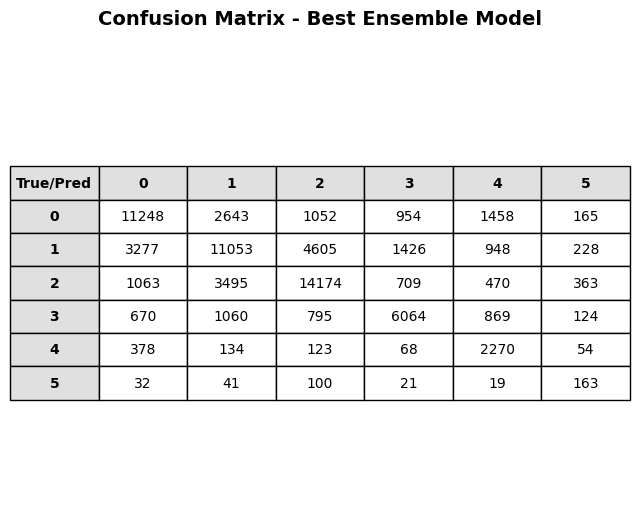

In [44]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# compute confusion matrix
cm = confusion_matrix(y_test, best_pred)

# create figure
fig, ax = plt.subplots(figsize=(8, 6))
ax.axis('tight')
ax.axis('off')

# create table data with headers
table_data = []

# header row
header = ['True/Pred'] + [str(i) for i in range(6)]
table_data.append(header)

# data rows
for i in range(6):
    row = [str(i)] + [str(cm[i, j]) for j in range(6)]
    table_data.append(row)

# create table
table = ax.table(cellText=table_data, loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2)

# bold the header row
for i in range(7):
    table[(0, i)].set_facecolor('#E0E0E0')
    table[(0, i)].set_text_props(weight='bold')

# bold the first column
for i in range(1, 7):
    table[(i, 0)].set_facecolor('#E0E0E0')
    table[(i, 0)].set_text_props(weight='bold')

plt.title('Confusion Matrix - Best Ensemble Model', fontsize=14, fontweight='bold', pad=20)
plt.savefig('../output/confusion_matrix_table.png', dpi=150, bbox_inches='tight')
plt.show()

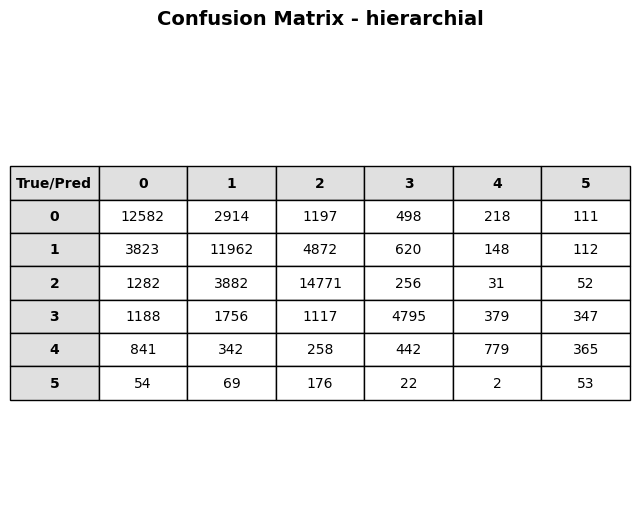

In [47]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# compute confusion matrix
cm = confusion_matrix(y_test, hier_pred)

# create figure
fig, ax = plt.subplots(figsize=(8, 6))
ax.axis('tight')
ax.axis('off')

# create table data with headers
table_data = []

# header row
header = ['True/Pred'] + [str(i) for i in range(6)]
table_data.append(header)

# data rows
for i in range(6):
    row = [str(i)] + [str(cm[i, j]) for j in range(6)]
    table_data.append(row)

# create table
table = ax.table(cellText=table_data, loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2)

# bold the header row
for i in range(7):
    table[(0, i)].set_facecolor('#E0E0E0')
    table[(0, i)].set_text_props(weight='bold')

# bold the first column
for i in range(1, 7):
    table[(i, 0)].set_facecolor('#E0E0E0')
    table[(i, 0)].set_text_props(weight='bold')

plt.title('Confusion Matrix - hierarchial', fontsize=14, fontweight='bold', pad=20)
plt.savefig('../output/confusion_matrix_table1.png', dpi=150, bbox_inches='tight')
plt.show()